In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

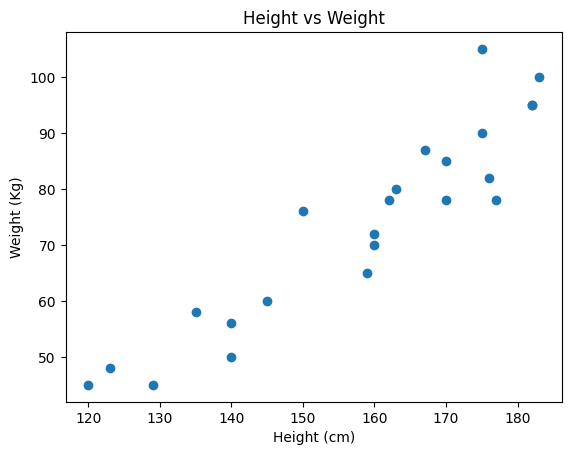

In [4]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (Kg)')
plt.title('Height vs Weight')

In [5]:
#Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


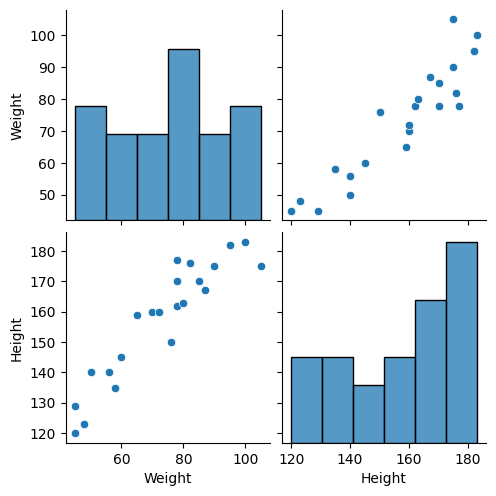

In [7]:
import seaborn as sns
sns.pairplot(df)

In [48]:
X = df[['Weight']]
np.array(X).shape


(23, 1)

In [49]:
X_series = df['Weight']
np.array(X)
np.array(X).shape


(23, 1)

In [50]:
y = df['Height']
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [51]:
# Training and Testing Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [52]:
X_train.shape

(17, 1)

In [53]:
#standardization
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [54]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

In [55]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [56]:
print("Coefficient",regression.coef_)
print("Interception",regression.intercept_)

Coefficient [17.2982057]
Interception 156.47058823529412


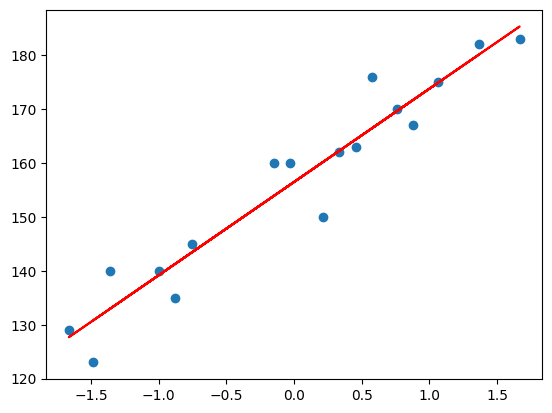

In [57]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

## Prediction of test data
1. predcted_hieght = intercept + coef(Wieght)
2. y_pred_test = 156.47 + 17.29 (X_test)

In [60]:
y_pred = regression.predict(X_test)

In [61]:
# Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605
R2 Score: 0.7360826717981276


In [62]:
#adjusted r2 score
def adjusted_r2_score(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)
n = len(y_test)
k = X_test.shape[1]
print("Adjusted R2 Score:", adjusted_r2_score(r2_score(y_test, y_pred), n, k))

Adjusted R2 Score: 0.6701033397476595


/var/folders/s0/smpstk6x2kd_pppyythh4r300000gn/T/ipykernel_73563/3184509202.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


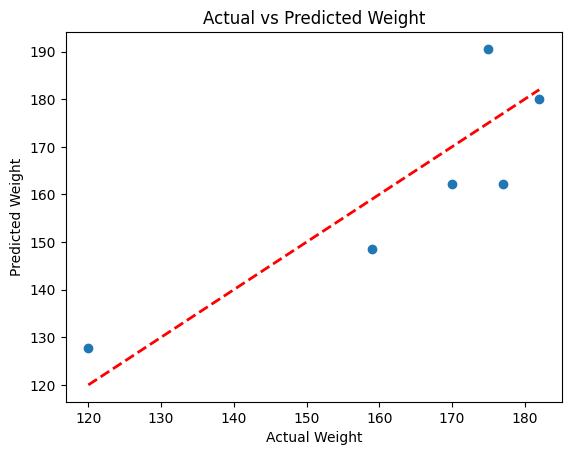

In [63]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('Actual vs Predicted Weight')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.show()

In [64]:
import statsmodels.api as sm

model = sm.OLS(y_train,X_train).fit()

In [65]:
predict = model.predict(X_test)
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 21 Jun 2025   Prob (F-statistic):                       0.664
Time:                        18:14:41   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/Users/sujairibrahim/My Studies/ML-KrishNaik/krishml/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [66]:
regression.predict(scalar.transform([[72]]))

/Users/sujairibrahim/My Studies/ML-KrishNaik/krishml/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])